# Space Economy: Early Stage or Pipe Dream?

**Thesis:** Launch costs have collapsed, satellite constellations are proliferating, and
private capital is flooding into space infrastructure. This thesis evaluates whether the
commercial space economy is a legitimate investable theme in the 2020s, or a long-duration
speculative bet with no near-term cash flows.

**This notebook investigates:**
1. Do space stocks behave like an established industry, or like a "speculative bet"?
2. Is volatility in the sector explainable by company activity, or by broad market sentiment?
3. Is there early evidence of maturing fundamentals (revenue growth, narrowing losses)?

**Data:** Space-sector stocks and ETFS from `yfinance` compared against broad market (SPY), growth/tech (QQQ), and speculative growth (ARKK) benchmarks.

## Configurations

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [ ]:
SPACE_STOCKS = ["RKLB", "ASTS", "PL", "BKSY", "SPCE"]
SPACE_ETFS = ["ARKX", "UFO"]
BENCHMARKS = ["SPY", "QQQ", "ARKK"]
ALL_TICKERS = SPACE_STOCKS + SPACE_ETFS + BENCHMARKS

START_DATE = "2021-04-30"  # adjust based on when your youngest ticker started trading
END_DATE = "2026-07-14" # future improvement: update this to today every day

**Note**: Some space-stocks, such as RKLB and ASTS only IPO'd in [2021] thus have a shorter range of data. The start data for analysis has been adjusted to the youngest ticker so as to avoid empty data in earlier years.


## Loading Data

In [3]:
def load_price_data(tickers, start, end):
    """Downloads daily adjusted close prices. Rows = dates, columns = tickers."""
    raw = yf.download(tickers, start=start, end=end, auto_adjust=True)
    prices = raw["Close"]
    prices = prices.dropna(axis=1, how="all") # Drops tickers that fail to download
    return prices

prices = load_price_data(ALL_TICKERS, START_DATE, END_DATE)

[*********************100%***********************]  10 of 10 completed


Testing

In [4]:
prices.tail()
prices.count().sort_values

<bound method Series.sort_values of Ticker
ARKK    1297
ARKX    1297
ASTS    1297
BKSY    1297
PL      1297
QQQ     1297
RKLB    1297
SPCE    1297
SPY     1297
UFO     1297
dtype: int64>

## Compute daily returns

In [5]:
def compute_daily_returns(prices):
    return prices.pct_change().dropna(how="all")

returns = compute_daily_returns(prices)

## Correlation Analysis

In [6]:
def compute_correlation_matrix(returns, tickers):
    return returns[tickers].corr().round(2)

space_tickers_present = [t for t in SPACE_STOCKS if t in returns.columns]
corr_space = compute_correlation_matrix(returns, space_tickers_present)
corr_space

Ticker,RKLB,ASTS,PL,BKSY,SPCE
Ticker,,,,,
RKLB,1.00,0.40,0.48,0.43,0.38
ASTS,0.40,1.00,0.31,0.30,0.31
PL,0.48,0.31,1.00,0.46,0.30
BKSY,0.43,0.30,0.46,1.00,0.30
SPCE,0.38,0.31,0.30,0.30,1.00


In [7]:
def compute_cross_correlation(returns, row_tickers, col_tickers):
    """
    Correlation of each row_ticker against each col_ticker only —
    e.g. space stocks (rows) vs benchmarks (columns) — rather than a full
    square matrix that also includes stock-vs-stock and benchmark-vs-benchmark.
    """
    cross_corr = pd.DataFrame(index=row_tickers, columns=col_tickers, dtype=float)
    for row in row_tickers:
        for col in col_tickers:
            cross_corr.loc[row, col] = returns[row].corr(returns[col])
    return cross_corr.round(2)

corr_vs_benchmarks = compute_cross_correlation(returns, space_tickers_present, BENCHMARKS)
corr_vs_benchmarks

,SPY,QQQ,ARKK
RKLB,0.43,0.45,0.53
ASTS,0.32,0.33,0.38
PL,0.38,0.39,0.46
BKSY,0.36,0.38,0.45
SPCE,0.35,0.37,0.51


This has what I need, but the data is presented in a way that's difficult to understand immediately. What would work better?

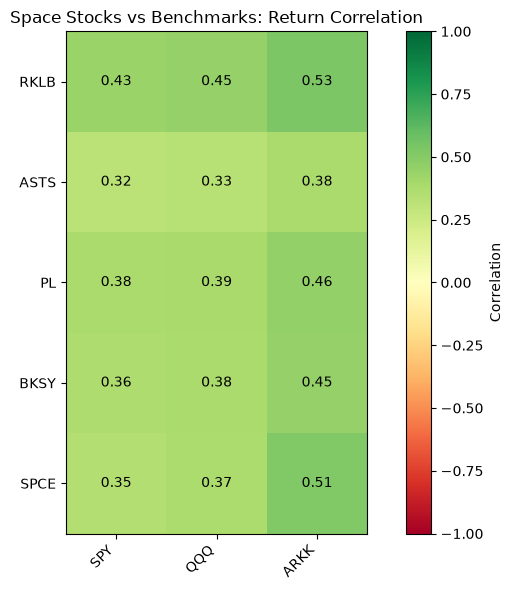

In [8]:
def plot_correlation_heatmap(corr_matrix, title="Correlation Matrix"):
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(corr_matrix, cmap="RdYlGn", vmin=-1, vmax=1)

    # Axis labels
    ax.set_xticks(range(len(corr_matrix.columns)))
    ax.set_yticks(range(len(corr_matrix.index)))
    ax.set_xticklabels(corr_matrix.columns, rotation=45, ha="right")
    ax.set_yticklabels(corr_matrix.index)

    # Annotate each cell with its correlation value
    for i in range(len(corr_matrix.index)):
        for j in range(len(corr_matrix.columns)):
            value = corr_matrix.iloc[i, j]
            # Use dark or light text depending on background so it stays readable
            text_color = "white" if abs(value) > 0.6 else "black"
            ax.text(j, i, f"{value:.2f}", ha="center", va="center", color=text_color)

    plt.colorbar(im, ax=ax, label="Correlation")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

plot_correlation_heatmap(corr_vs_benchmarks, title="Space Stocks vs Benchmarks: Return Correlation")


Overall, space stocks correlate more strongly with ARKK, indicating speculative growth. However, it's not strongly correlated, evidencing an independent movement of the market.

## Beta and regression analysis

In [9]:
def compute_beta_and_r2(returns, ticker, benchmark="SPY"):
    df = returns[[ticker, benchmark]].dropna()
    slope, intercept, r_value, p_value, std_err = stats.linregress(df[benchmark], df[ticker])
    return {
        "ticker": ticker,
        "beta": round(slope, 3),
        "r_squared": round(r_value ** 2, 3),
        "p_value": round(p_value, 5),
        "n_observations": len(df),
    }

beta_table = pd.DataFrame([
    compute_beta_and_r2(returns, t, "SPY") for t in space_tickers_present + SPACE_ETFS
    if t in returns.columns
]).set_index("ticker")
beta_table

,beta,r_squared,p_value,n_observations
ticker,,,,
RKLB,2.036,0.188,0.0,1296
ASTS,2.082,0.101,0.0,1296
PL,1.795,0.145,0.0,1296
BKSY,2.089,0.131,0.0,1296
SPCE,2.038,0.123,0.0,1296
ARKX,1.279,0.608,0.0,1296
UFO,1.165,0.422,0.0,1296


This indicates that when the market moves, the stocks are very volatile. But it also shows that its day to day variation is very unrelated to market, it's driven by something else.
ETFs have a higher r value, which they should. They're diversified to average out and move more like the market.

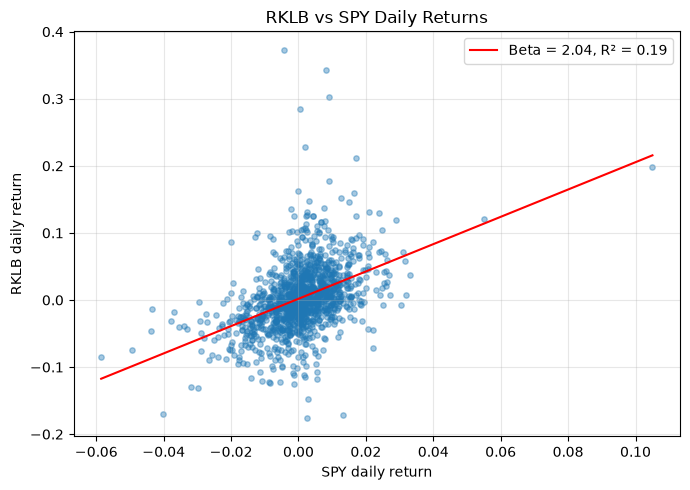

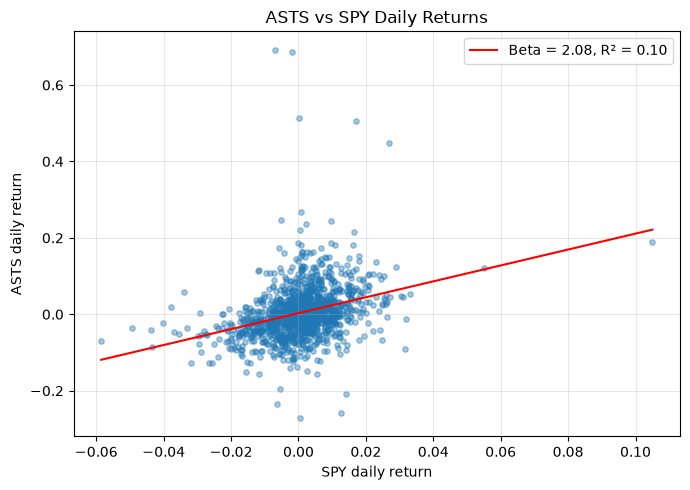

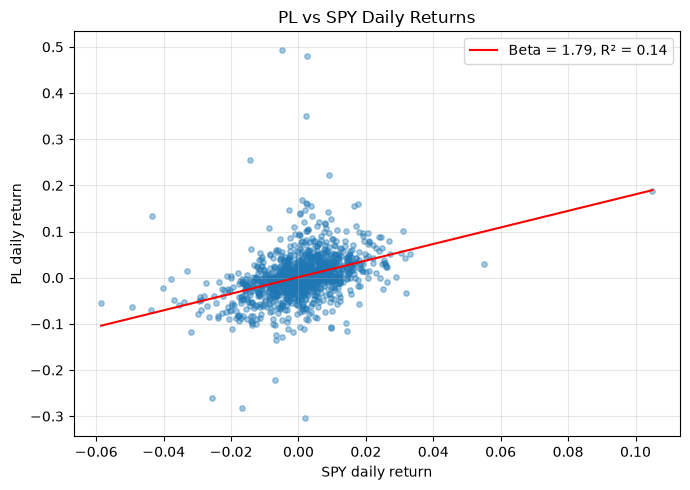

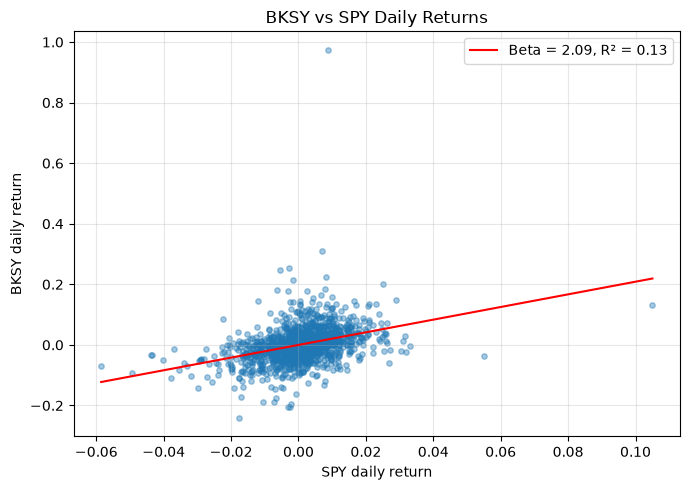

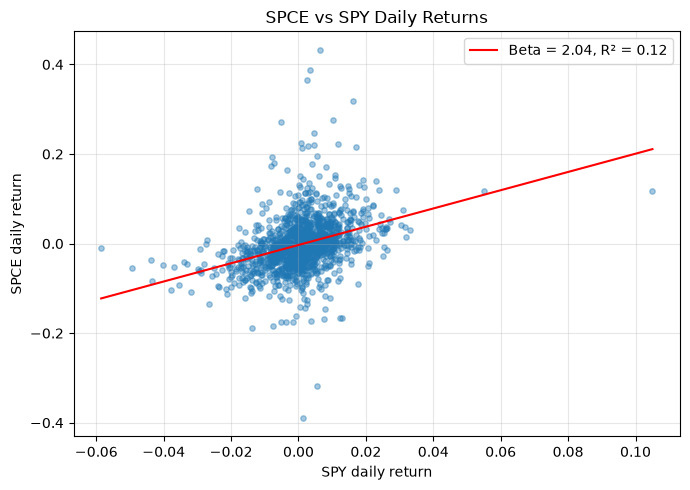

In [13]:
def plot_regression_scatter(returns, ticker, benchmark="SPY"):
    df = returns[[ticker, benchmark]].dropna()
    slope, intercept, r_value, p_value, std_err = stats.linregress(df[benchmark], df[ticker])

    plt.figure(figsize=(7, 5))
    plt.scatter(df[benchmark], df[ticker], alpha=0.4, s=15)
    x_line = np.linspace(df[benchmark].min(), df[benchmark].max(), 100)
    y_line = slope * x_line + intercept
    plt.plot(x_line, y_line, color="red", label=f"Beta = {slope:.2f}, R² = {r_value**2:.2f}")
    plt.title(f"{ticker} vs {benchmark} Daily Returns")
    plt.xlabel(f"{benchmark} daily return")
    plt.ylabel(f"{ticker} daily return")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

for ticker in space_tickers_present:
    plot_regression_scatter(returns, ticker, "SPY")

## Volatility and drawdown

In [14]:
def compute_volatility_and_drawdown(prices, returns, ticker):
    daily_std = returns[ticker].std()
    annualised_vol = daily_std * np.sqrt(252)

    price_series = prices[ticker].dropna()
    running_max = price_series.cummax()
    drawdown_series = (price_series - running_max) / running_max
    max_drawdown = drawdown_series.min()

    return {
        "ticker": ticker,
        "annualised_volatility_pct": round(annualised_vol * 100, 2),
        "max_drawdown_pct": round(max_drawdown * 100, 2),
    }

vol_table = pd.DataFrame([
    compute_volatility_and_drawdown(prices, returns, t)
    for t in ALL_TICKERS if t in returns.columns
]).set_index("ticker")
vol_table.sort_values("annualised_volatility_pct", ascending=False)


,annualised_volatility_pct,max_drawdown_pct
ticker,,
ASTS,111.39,-85.57
SPCE,98.72,-99.81
BKSY,98.15,-96.04
PL,80.22,-85.73
RKLB,79.87,-82.96
ARKK,46.15,-77.17
UFO,30.54,-50.33
ARKX,27.92,-43.61
QQQ,22.55,-35.12


Significantly large volatility and drawdown in comparison to SPY.

## Cumulative returns and rolling volatility

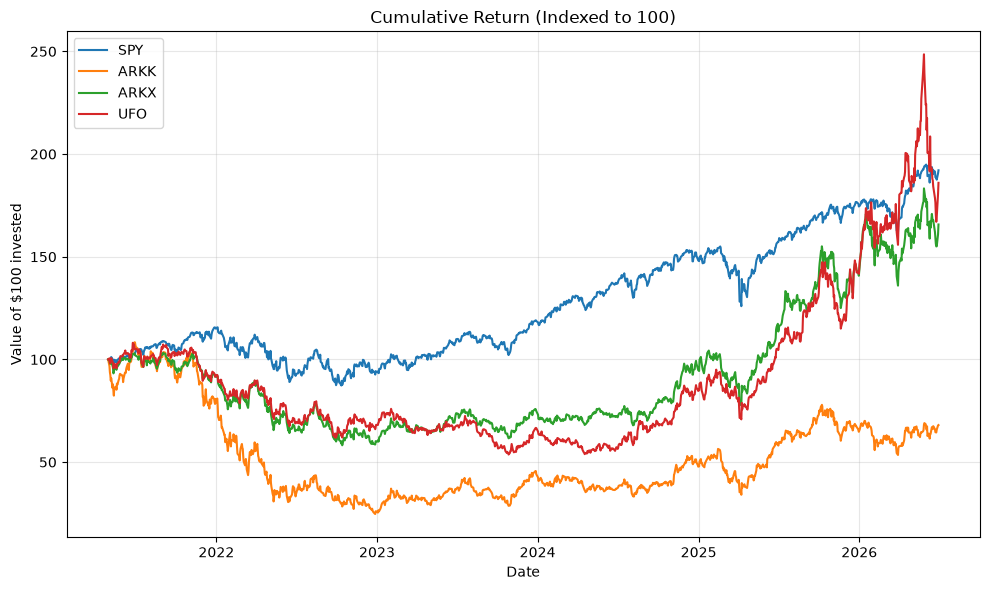

In [15]:
def plot_cumulative_returns(prices, tickers):
    subset = prices[tickers].dropna()
    indexed = subset / subset.iloc[0] * 100

    plt.figure(figsize=(10, 6))
    for ticker in tickers:
        plt.plot(indexed.index, indexed[ticker], label=ticker)
    plt.title("Cumulative Return (Indexed to 100)")
    plt.xlabel("Date")
    plt.ylabel("Value of $100 invested")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

cumulative_tickers = ["SPY", "ARKK"] + [t for t in SPACE_ETFS if t in prices.columns]
plot_cumulative_returns(prices, cumulative_tickers)

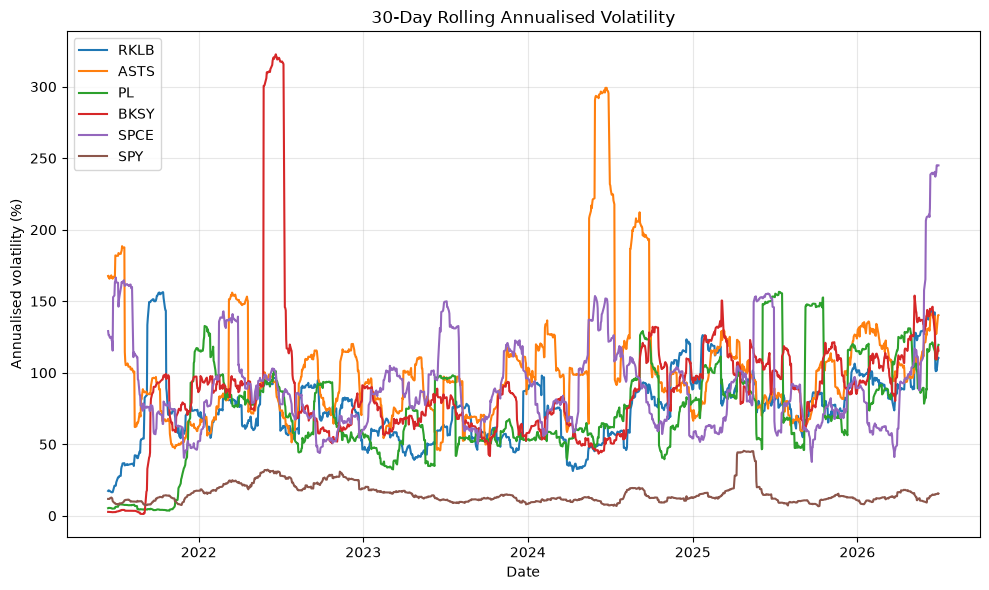

In [16]:
def plot_rolling_volatility(returns, tickers, window=30):
    plt.figure(figsize=(10, 6))
    for ticker in tickers:
        rolling_vol = returns[ticker].rolling(window).std() * np.sqrt(252) * 100
        plt.plot(rolling_vol.index, rolling_vol, label=ticker)
    plt.title(f"{window}-Day Rolling Annualised Volatility")
    plt.xlabel("Date")
    plt.ylabel("Annualised volatility (%)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_rolling_volatility(returns, space_tickers_present + ["SPY"])

Need to note sharp spikes and match it with real news, which can explain the volatility.

## Context
Need to pull data points about each company to indicate whether revenue is growing, lossess narrowing etc 

## Verdict
